# Task 1

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB


## Data loading and exploration

In [3]:
DATA_DIR = Path('.').resolve().parent / 'data'
df = pd.read_json(DATA_DIR / 'dataset.json')
df.head()

,geoname_id,name,ascii_name,alternate_names,feature_class,feature_code,country_code,cou_name_en,country_code_2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date,label_en,coordinates
0,6534819,Cerreto Castello,Cerreto Castello,None,P,PPLA3,IT,Italy,NaN,12,BI,096087,NaN,568,264.0,255,Europe/Rome,2019-03-08,Italy,"{'lon': 8.16082, 'lat': 45.56446}"
1,6534828,Garbagnate Monastero,Garbagnate Monastero,None,P,PPLA3,IT,Italy,NaN,09,LC,097037,NaN,2186,NaN,301,Europe/Rome,2012-02-15,Italy,"{'lon': 9.30144, 'lat': 45.77338}"
2,6534843,Monterosso Grana,Monterosso Grana,None,P,PPLA3,IT,Italy,NaN,12,CN,004139,NaN,259,720.0,730,Europe/Rome,2014-01-11,Italy,"{'lon': 7.32293, 'lat': 44.40823}"
3,6534893,Olivola,Olivola,None,P,PPLA3,IT,Italy,NaN,12,AL,006118,NaN,92,280.0,270,Europe/Rome,2014-01-19,Italy,"{'lon': 8.36784, 'lat': 45.03725}"
4,6534895,Pietra Marazzi,Pietra Marazzi,None,P,PPLA3,IT,Italy,NaN,12,AL,006129,NaN,783,95.0,91,Europe/Rome,2014-01-11,Italy,"{'lon': 8.66854, 'lat': 44.94265}"


In [4]:
poland = df.loc[df['country_code'] == 'PL', ['name', 'coordinates']]
poland.reset_index(inplace=True)
poland = poland.join(pd.json_normalize(poland['coordinates']))
poland.drop(['coordinates'], axis=1, inplace=True)

print(poland.isna().sum())
poland.head()

index    0
name     0
lon      0
lat      0
dtype: int64


,index,name,lon,lat
0,546,Żurowa,21.16894,49.82636
1,547,Wyśmierzyce,20.81394,51.62494
2,548,Wólka Tanewska,22.26113,50.50005
3,549,Wiśniowa,20.11502,49.78780
4,550,Węgorzewo,21.73720,54.21567


In [5]:
coords_rad = np.radians(poland[['lat', 'lon']].to_numpy())
dist = haversine_distances(coords_rad) * 6371
dist[:6, :6]

array([[  0.        , 201.54734522, 107.99906142,  75.7512981 ,
        489.61099146,  24.98910247],
       [201.54734522,   0.        , 160.84594446, 210.12324215,
        294.64377677, 176.56392304],
       [107.99906142, 160.84594446,   0.        , 172.21407396,
        414.68404673,  94.49131643],
       [ 75.7512981 , 210.12324215, 172.21407396,   0.        ,
        504.68786152,  78.51490838],
       [489.61099146, 294.64377677, 414.68404673, 504.68786152,
          0.        , 465.03569161],
       [ 24.98910247, 176.56392304,  94.49131643,  78.51490838,
        465.03569161,   0.        ]])

In [6]:
G = (dist <= 50)
print(G.mean())
G[:6, :6]

0.034836399469277864


array([[ True, False, False, False, False,  True],
       [False,  True, False, False, False, False],
       [False, False,  True, False, False, False],
       [False, False, False,  True, False, False],
       [False, False, False, False,  True, False],
       [ True, False, False, False, False,  True]])

For d=50 we get a very sparse graph, better to use adj list.

## Modeling the problem as ILP/LP

Let $N$ be the total number of cities, and let $D$ be the maximum allowed distance from a city to the closest restaurant. This implicitly defines a graph $G = (V, E)$, where each city is a vertex, and two nodes $u, v$ are connected by an edge iff the distance between them is at most $D$.

Let $x_i \in \{0, 1\}$ be a variable indicating whether we open a restaurant in the $i$-th city. The ILP is then

\begin{aligned}
& \text{minimize} && \sum_{i=1}^{N} x_i \\
& \text{subject to} && \sum_{j \in \mathcal{N}(i)} x_j \ge 1, \quad \forall i \in \{1, \dots, N\} \\
& && x_i \in \{0, 1\}
\end{aligned}

In [7]:
def get_graph(d: int, total_cities=1900):
    mask = (dist[:total_cities, :total_cities] <= d)
    return [np.where(row)[0] for row in mask]

G = get_graph(50)
G[:2]

[array([   0,    5,    8,   27,   28,  117,  118,  144,  145,  155,  241,
         267,  347,  358,  361,  365,  453,  463,  470,  473,  492,  564,
         567,  674,  757,  762,  769,  770,  777,  782,  855,  883,  970,
         998, 1071, 1186, 1191, 1281, 1294, 1299, 1302, 1379, 1386, 1387,
        1418, 1419, 1485, 1486, 1491, 1497, 1499, 1503, 1567, 1573, 1580,
        1603, 1604, 1687, 1700, 1708, 1710, 1715, 1716, 1721, 1722, 1773,
        1799, 1800, 1807, 1865, 1884, 1887]),
 array([   1,   40,   51,  130,  134,  152,  261,  370,  458,  476,  659,
         679,  680,  685,  688,  689,  758,  781,  785,  975,  993, 1078,
        1080, 1098, 1101, 1107, 1196, 1199, 1293, 1305, 1307, 1383, 1384,
        1391, 1398, 1409, 1502, 1562, 1577, 1776, 1789, 1868, 1873, 1891])]

I was not able to get a license for Gurobi,  but all of following instances have no more than 2000 variables, which is solvable with free license.

In [8]:
def create_lp(ilp: bool, graph, logs=False):
    total_cities = len(graph)
    m = gp.Model()
    m.setParam('OutputFlag', logs)

    if ilp:
        x = m.addVars(total_cities, vtype=GRB.BINARY)
    else:
        x = m.addVars(total_cities, vtype=GRB.CONTINUOUS, lb=0.0, ub=1.0)

    for v in range(total_cities):
        m.addConstr(gp.quicksum(x[j] for j in graph[v]) >= 1)

    m.setObjective(x.sum(), GRB.MINIMIZE)
    m.optimize()

    return m

## Task 1.1 - solving ILP

In [124]:
results = []
sizes = [500, 1000, 1100, 1200, 1300, 1400, 1500]

for n in sizes:
    print(f"Solving for N={n}")
    graph = get_graph(d=50, total_cities=n)
    model = create_lp(ilp=True, graph=graph, logs=0)

    if model.status == GRB.OPTIMAL:
        obj = model.objVal
    else:
        obj = "N/A"

    results.append({
        "Cities": n,
        "Result": obj,
        "Runtime": model.Runtime,

    })

df_results = pd.DataFrame(results)
print(df_results)

Solving for N=500
Solving for N=1000
Solving for N=1100
Solving for N=1200
Solving for N=1300
Solving for N=1400
Solving for N=1500
   Cities  Result    Runtime
0     500    43.0   0.028538
1    1000    48.0   0.831379
2    1100    49.0   1.466439
3    1200    49.0   2.258964
4    1300    49.0   3.684617
5    1400    49.0  16.908454
6    1500    50.0  96.821266


As we can see, for $N \leq 1300$ it was almost instant, for larger $N$ it took considerably more time. I did a test for $N=1900$, and it found solution with $N=50$ and lower bound of $48.1$ within one minute, proving we need either 49 or 50 locations. It did not, however converge in next 10 minutes, so i decided to stop it, as by homework requirements $N>=500$ is considered large enough.

## Task 1.3 - solving relaxed problem

In [127]:
results = []
sizes = [500, 1000, 1100, 1200, 1300, 1400, 1500, 1900, 2000]

for n in sizes:
    print(f"Solving for N={n}")
    graph = get_graph(d=50, total_cities=n)
    model = create_lp(ilp=False, graph=graph, logs=0)

    if model.status == GRB.OPTIMAL:
        obj = model.objVal
    else:
        obj = "N/A"

    results.append({
        "Cities": n,
        "Result": obj,
        "Runtime": model.Runtime,

    })

df_results = pd.DataFrame(results)
print(df_results)

Solving for N=500
Solving for N=1000
Solving for N=1100
Solving for N=1200
Solving for N=1300
Solving for N=1400
Solving for N=1500
Solving for N=1900
Solving for N=2000
   Cities     Result   Runtime
0     500  42.617834  0.007143
1    1000  46.346470  0.063321
2    1100  46.519137  0.099413
3    1200  46.674640  0.097228
4    1300  46.483933  0.122412
5    1400  46.693628  0.139778
6    1500  46.609398  0.144715
7    1900  46.449439  0.252801
8    2000  46.316204  0.241860


This time it finds optimum in less than a second for every instance free Gurobi allows (max. 2000 variables).

## Task 1.2
Let's use $N = 1000$. Solver found solution to ILP in less than a second, and it fulfills requirement $>500$. Now We need to find a minimum. In optimal solution, we had to open exactly $48$ restaurants. For each $k$ in $\{1 \dots K\}$ we need to find a minimum distance, such that we can open no more than $k$ restaurants, and cover every city. I will use the following lemma:

**Lemma** Let $\mathcal{D} = \{dist(u, v) : u, v \text{ are cities}\}$. Then for every $k$ the solution to above problem is in $\mathcal{D}$.

It is obvious, informal argument to save some typing is this: because $\mathcal{D}$ is finite, so for any $d \notin \mathcal{D}$ there is largest $d'$ strictly smaller than $d$. Using $d'$ does not affect graph structure, so it is also a feasible solution, so $d$ can't be optimal.

That means, that for each $k$ we can just binary search over $\mathcal{D}$, and using ILP from $1.1$, check if optimal solution is $\leq k$.

In [19]:
N = 1000
all_d = np.unique(dist[:N, :N])
all_d.sort()

def b_search(k: int):
    l, r = 0, len(all_d) - 1
    res_id = None
    while l <= r:
        mid = (l+r) // 2
        graph = get_graph(all_d[mid], total_cities=N)
        m = create_lp(ilp=True, graph=graph, logs=False)
        if m.status != GRB.OPTIMAL:
            raise RuntimeError("Optimum not found")
        best_k = m.objVal

        if best_k <= k:
            res_id = mid
            r = mid - 1
        else:
            l = mid + 1
    return all_d[res_id]


results = []
max_k = 48

for k in range(1, max_k+1):
    print(f"Calculating for k={k}")
    min_dist = b_search(k)

    results.append({
        "k ": k,
        "Min. Distance": min_dist
    })


df = pd.DataFrame(results)

Calculating for k=1
Calculating for k=2
Calculating for k=3
Calculating for k=4
Calculating for k=5
Calculating for k=6
Calculating for k=7
Calculating for k=8
Calculating for k=9
Calculating for k=10
Calculating for k=11
Calculating for k=12
Calculating for k=13
Calculating for k=14
Calculating for k=15
Calculating for k=16
Calculating for k=17
Calculating for k=18
Calculating for k=19
Calculating for k=20
Calculating for k=21
Calculating for k=22
Calculating for k=23
Calculating for k=24
Calculating for k=25
Calculating for k=26
Calculating for k=27
Calculating for k=28
Calculating for k=29
Calculating for k=30
Calculating for k=31
Calculating for k=32
Calculating for k=33
Calculating for k=34
Calculating for k=35
Calculating for k=36
Calculating for k=37
Calculating for k=38
Calculating for k=39
Calculating for k=40
Calculating for k=41
Calculating for k=42
Calculating for k=43
Calculating for k=44
Calculating for k=45
Calculating for k=46
Calculating for k=47
Calculating for k=48


In [27]:
df.rename(columns={'k ': 'k'}, inplace=True)
df.set_index('k', inplace=True)
df.head()

,Min. Distance
k,
1,386.760220
2,307.516779
3,247.266876
4,196.372048
5,179.860644


In [28]:
df.tail()

,Min. Distance
k,
44,52.596686
45,52.166000
46,51.484320
47,50.581579
48,49.686152


For $k=48$, we got slightly less than $50$, which is consistent with results of task $1.1$. Moreover the results are, as expected, decreasing with $k$.

## Task 2

In [29]:
from ortools.linear_solver import pywraplp
from scipy.optimize import linprog
from scipy.sparse import coo_matrix
import time

def solve_ortools(ilp: bool, graph, logs=False):

    solver_name = "SCIP" if ilp else "GLOP"
    solver: pywraplp.Solver = pywraplp.Solver.CreateSolver(solver_name)

    total_cities = len(graph)
    if logs:
        solver.EnableOutput()

    if ilp:
        x = [solver.BoolVar(f"{i}") for i in range(total_cities)]
    else:
        x = [solver.NumVar(0.0, 1.0, f"{i}") for i in range(total_cities)]

    for v in range(total_cities):
        solver.Add(sum(x[j] for j in graph[v]) >= 1)

    solver.Minimize(sum(x))
    status = solver.Solve()
    if status != pywraplp.Solver.OPTIMAL:
        raise RuntimeError("Did not solve")

    return {
        "result": solver.Objective().Value(),
        "time": solver.wall_time()
    }

def solve_scipy(graph):

    n = len(graph)
    c = np.ones(n)

    rows = []
    cols = []
    data = []

    for i, neighbors in enumerate(graph):
        for j in neighbors:
            rows.append(i)
            cols.append(j)
            data.append(-1)

    A_ub = coo_matrix((data, (rows, cols)), shape=(n, n))
    b_ub = -np.ones(n)

    start = time.time()
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(0, 1), method='highs')
    end = time.time()

    if not res.success:
        raise RuntimeError(f"SciPy failed: {res.message}")

    return {"result": res.fun, "time": end - start}

In [30]:
lp_results = []
lp_sizes = [500, 1000, 1100, 1200, 1300, 1400, 1500, 1900, 2000]
ilp=False
for n in lp_sizes:
    print(f"Solving for N={n}")
    graph = get_graph(d=50, total_cities=n)

    print("Solving with ORTOOLS")
    res = solve_ortools(ilp, graph)
    lp_results.append({
        "size": n,
        "solver": "OR-Tools",
        "time": res["time"] / 1000.0,
        "objective": res["result"],
        "type": "ILP" if ilp else "LP"
    })

    print("Solving with GRUOBI")
    model = create_lp(ilp=ilp, graph=graph)
    if model.status != GRB.OPTIMAL:
        raise RuntimeError("Gruobi did not calculate optimum")

    print("Solving with SciPY")
    lp_results.append({
        "size": n,
        "solver": "Gurobi",
        "time": model.Runtime,
        "objective": model.objVal,
        "type": "ILP" if ilp else "LP"
    })

    if not ilp:
        res = solve_scipy(graph)
        lp_results.append({
            "size": n,
            "solver": "SciPy",
            "time": res["time"],
            "objective": res["result"],
            "type": "LP"
        })


Solving for N=500
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1000
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1100
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1200
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1300
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1400
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1500
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1900
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=2000
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY


In [31]:
df_lp_results = pd.DataFrame(lp_results)
df_lp_results

,size,solver,time,objective,type
0,500,OR-Tools,0.027000,42.617834,LP
1,500,Gurobi,0.006037,42.617834,LP
2,500,SciPy,0.012776,42.617834,LP
3,1000,OR-Tools,0.123000,46.346470,LP
4,1000,Gurobi,0.068206,46.346470,LP
5,1000,SciPy,0.112487,46.346470,LP
6,1100,OR-Tools,0.153000,46.519137,LP
7,1100,Gurobi,0.083518,46.519137,LP
8,1100,SciPy,0.140424,46.519137,LP
9,1200,OR-Tools,0.207000,46.674640,LP


In [32]:
ilp_results = []
ilp_sizes = [50, 100, 200, 400, 500, 1000]
ilp=True
for n in ilp_sizes:
    print(f"Solving for N={n}")
    graph = get_graph(d=50, total_cities=n)

    print("Solving with ORTOOLS")
    res = solve_ortools(ilp, graph)
    ilp_results.append({
        "size": n,
        "solver": "OR-Tools",
        "time": res["time"] / 1000.0,
        "objective": res["result"],
        "type": "ILP" if ilp else "LP"
    })

    print("Solving with GRUOBI")
    model = create_lp(ilp=ilp, graph=graph)
    if model.status != GRB.OPTIMAL:
        raise RuntimeError("Gruobi did not calculate optimum")

    print("Solving with SciPY")
    ilp_results.append({
        "size": n,
        "solver": "Gurobi",
        "time": model.Runtime,
        "objective": model.objVal,
        "type": "ILP" if ilp else "LP"
    })

    if not ilp:
        res = solve_scipy(graph)
        ilp_results.append({
            "size": n,
            "solver": "SciPy",
            "time": res["time"],
            "objective": res["result"],
            "type": "LP"
        })


Solving for N=50
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=100
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=200
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=400
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=500
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY
Solving for N=1000
Solving with ORTOOLS
Solving with GRUOBI
Solving with SciPY


In [33]:
df_ilp_results = pd.DataFrame(ilp_results)
df_ilp_results

,size,solver,time,objective,type
0,50,OR-Tools,0.003000,24.0,ILP
1,50,Gurobi,0.000746,24.0,ILP
2,100,OR-Tools,0.003000,40.0,ILP
3,100,Gurobi,0.000727,40.0,ILP
4,200,OR-Tools,0.006000,44.0,ILP
5,200,Gurobi,0.001018,44.0,ILP
6,400,OR-Tools,0.028000,43.0,ILP
7,400,Gurobi,0.008605,43.0,ILP
8,500,OR-Tools,0.138000,43.0,ILP
9,500,Gurobi,0.025663,43.0,ILP


SciPy does not support ILP's.

The objective values is the same for all tested solvers, both for LP's and ILPs

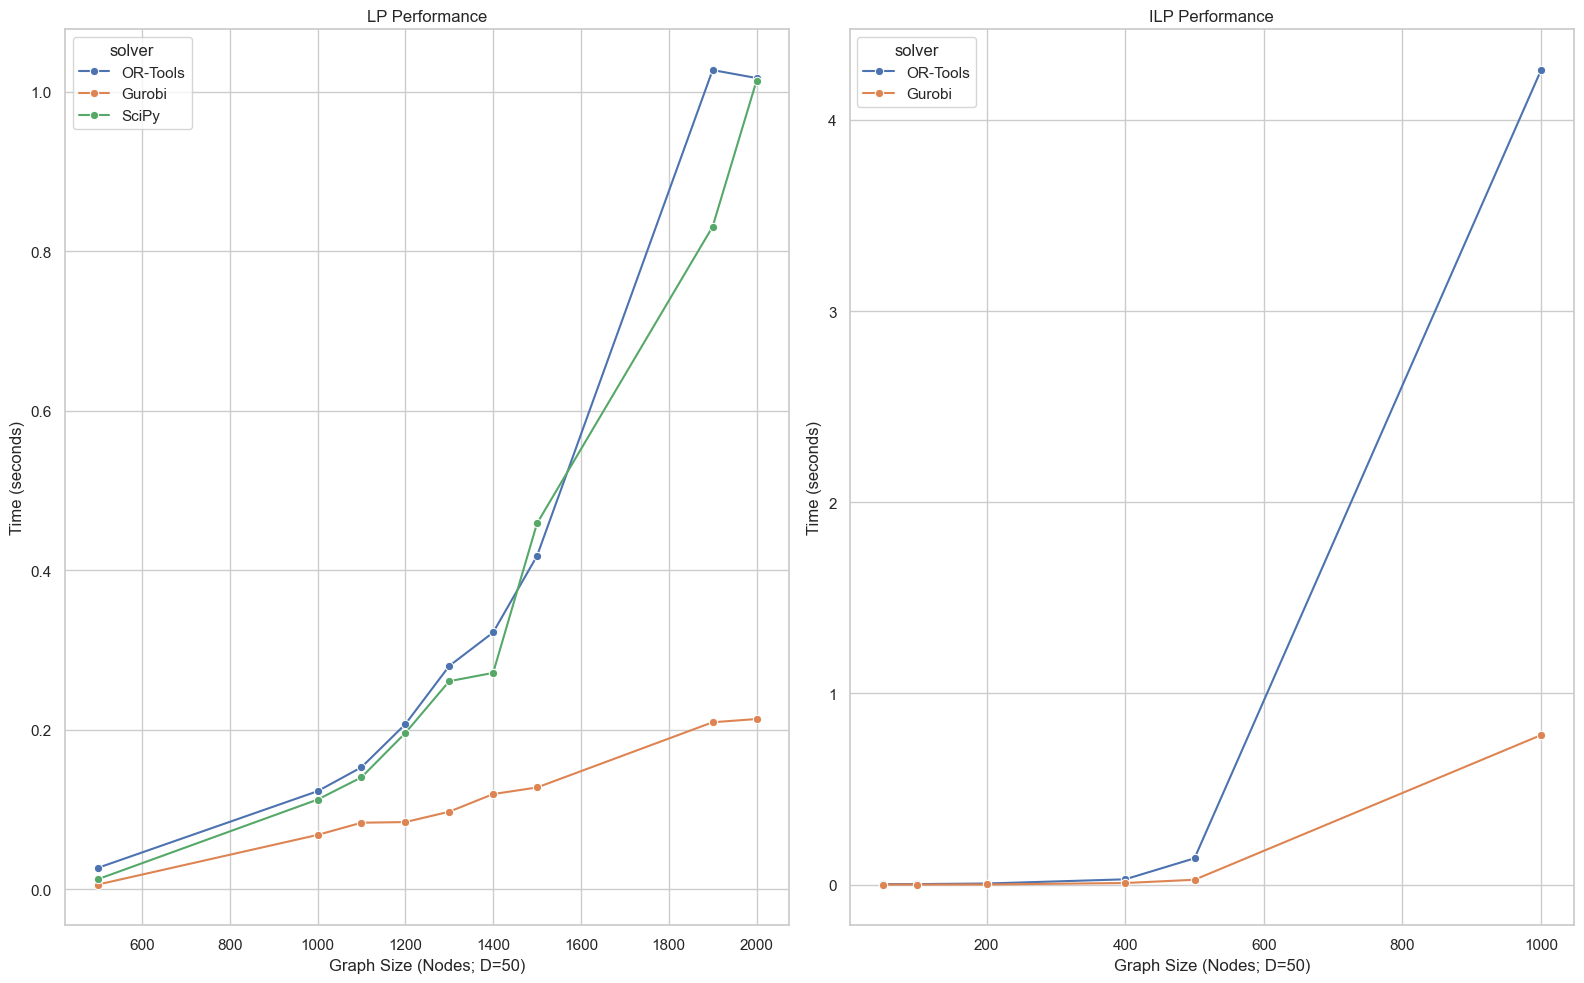

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.lineplot(
    data=df_lp_results,
    x="size",
    y="time",
    hue="solver",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("LP Performance")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_xlabel("Graph Size (Nodes; D=50)")

sns.lineplot(
    data=df_ilp_results,
    x="size",
    y="time",
    hue="solver",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("ILP Performance")
axes[1].set_ylabel("Time (seconds)")
axes[1].set_xlabel("Graph Size (Nodes; D=50)")

plt.tight_layout()
plt.show()

Gurobi is the winner!